In [3]:
from pathlib import Path
import pandas as pd 
import numpy as np 

In [4]:
data_folder = Path(".")

payroll_path=data_folder/"payroll.csv"

In [6]:
payroll=pd.read_csv(payroll_path)

In [8]:
payroll.shape

(60000, 5)

In [9]:
payroll.describe

<bound method NDFrame.describe of        payroll_id  employee_id pay_month net_salary   bonus
0               1       8164.0   2025/08      -5000     0.0
1               2       5491.0   2025-08      42000     0.0
2               3       6056.0   2025-08      42000  -100.0
3               4       2883.0   2025-08      65000     0.0
4               5       9775.0   2025-08      65000  -100.0
...           ...          ...       ...        ...     ...
59995       59996       7705.0  Aug-2025        NaN  2000.0
59996       59997       1135.0       NaN      -5000  5000.0
59997       59998       2163.0       NaN      25000     NaN
59998       59999       5537.0       NaN    ₹45,000  2000.0
59999       60000       7924.0  Aug-2025        NaN     0.0

[60000 rows x 5 columns]>

<Axes: >

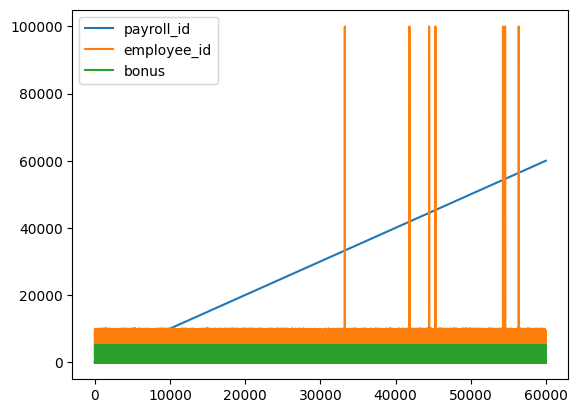

In [10]:
payroll.plot()

In [11]:
payroll.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   payroll_id   60000 non-null  int64  
 1   employee_id  59995 non-null  float64
 2   pay_month    44885 non-null  object 
 3   net_salary   50134 non-null  object 
 4   bonus        47843 non-null  float64
dtypes: float64(2), int64(1), object(2)
memory usage: 2.3+ MB


In [12]:
payroll.head(10)

,payroll_id,employee_id,pay_month,net_salary,bonus
0,1,8164.0,2025/08,-5000,0.0
1,2,5491.0,2025-08,42000,0.0
2,3,6056.0,2025-08,42000,-100.0
3,4,2883.0,2025-08,65000,0.0
4,5,9775.0,2025-08,65000,-100.0
5,6,9530.0,2025/08,25000,-100.0
6,7,2150.0,2025-08,NaN,2000.0
7,8,9036.0,NaN,25000,2000.0
8,9,4768.0,NaN,65000,0.0
9,10,3326.0,NaN,NaN,-100.0


In [13]:
payroll.isnull().sum()

payroll_id         0
employee_id        5
pay_month      15115
net_salary      9866
bonus          12157
dtype: int64

In [14]:
(payroll=="").sum()

payroll_id     0
employee_id    0
pay_month      0
net_salary     0
bonus          0
dtype: int64

In [15]:
(payroll.apply(lambda x : x.astype(str).str.strip()=="")).sum()

payroll_id     0
employee_id    0
pay_month      0
net_salary     0
bonus          0
dtype: int64

In [16]:
clean_payroll=payroll.copy()

In [18]:
clean_payroll.head()

,payroll_id,employee_id,pay_month,net_salary,bonus
0,1,8164.0,2025/08,-5000,0.0
1,2,5491.0,2025-08,42000,0.0
2,3,6056.0,2025-08,42000,-100.0
3,4,2883.0,2025-08,65000,0.0
4,5,9775.0,2025-08,65000,-100.0


In [19]:
clean_payroll["payroll_id"].duplicated().sum()

0

In [20]:
clean_payroll.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   payroll_id   60000 non-null  int64  
 1   employee_id  59995 non-null  float64
 2   pay_month    44885 non-null  object 
 3   net_salary   50134 non-null  object 
 4   bonus        47843 non-null  float64
dtypes: float64(2), int64(1), object(2)
memory usage: 2.3+ MB


In [21]:
clean_payroll.columns=(
    clean_payroll.columns
    .str.strip()
    .str.lower()
    .str.replace(r"_+","_",regex=True)
)

In [22]:
clean_payroll.columns

Index(['payroll_id', 'employee_id', 'pay_month', 'net_salary', 'bonus'], dtype='object')

In [23]:
clean_payroll=clean_payroll.replace(
    r"^\s*$",
    np.nan,
    regex=True
)

In [25]:
clean_payroll["employee_id"] = pd.to_numeric(
    clean_payroll["employee_id"],
    errors="coerce").astype("Int64")

In [26]:
employee_path= data_folder / "employees-cleaned.csv"

In [27]:
employee= pd.read_csv(employee_path)

In [28]:
invalid_employee_ids = clean_payroll[
    ~clean_payroll["employee_id"].isin(employee["employee__id"])
    & clean_payroll["employee_id"].notna()
]
 
invalid_employee_ids

,payroll_id,employee_id,pay_month,net_salary,bonus
33253,33254,99999,2025-08,65000,2000.0
41854,41855,99999,2025-08,25000,NaN
44475,44476,99999,NaN,42000,5000.0
45313,45314,99999,NaN,42000,NaN
54300,54301,99999,2025-08,-5000,-100.0
54584,54585,99999,2025-08,42000,-100.0
56394,56395,99999,2025-08,NaN,2000.0


In [29]:
clean_payroll= clean_payroll[ clean_payroll["employee_id"].isin(employee["employee__id"])].copy()

In [30]:
clean_payroll["employee_id"].isna().sum()

0

In [31]:
len(
    clean_payroll[
    ~clean_payroll["employee_id"].isin(
        employee["employee__id"]
    )
    ]
)

0

In [36]:
clean_payroll["pay_month"]=pd.to_datetime(
    clean_payroll["pay_month"],
    errors="coerce"
)

In [41]:
clean_payroll["pay_month"] = (
    clean_payroll["pay_month"]
    .dt.asfreq("M")
)

In [42]:
clean_payroll["pay_month"].value_counts(
    dropna=False
)

pay_month
2025-08    44876
NaT        15112
Freq: M, Name: count, dtype: int64

In [43]:
clean_payroll["net_salary"] = (
    clean_payroll["net_salary"]
    .astype("string")
    .str.strip()
    .str.replace("₹", "", regex=False)
    .str.replace(",", "", regex=False)
)

In [44]:
clean_payroll["net_salary"] = pd.to_numeric(
    clean_payroll["net_salary"],
    errors="coerce"
)

In [45]:
clean_payroll.loc[
    clean_payroll["net_salary"] < 0,
    "net_salary"
] = np.nan
 

In [46]:
clean_payroll["net_salary"].isna().sum()

19887

In [48]:
clean_payroll.dropna(
    subset=["net_salary"]
)

,payroll_id,employee_id,pay_month,net_salary,bonus
1,2,5491,2025-08,42000,0.0
2,3,6056,2025-08,42000,-100.0
3,4,2883,2025-08,65000,0.0
4,5,9775,2025-08,65000,-100.0
5,6,9530,2025-08,25000,-100.0
...,...,...,...,...,...
59991,59992,1700,NaT,45000,-100.0
59992,59993,4717,2025-08,25000,-100.0
59994,59995,4474,2025-08,25000,NaN
59997,59998,2163,NaT,25000,NaN


In [49]:
clean_payroll["bonus"] = pd.to_numeric(
    clean_payroll["bonus"],errors="coerce"
)

In [51]:
clean_payroll[ clean_payroll["bonus"]<0]

,payroll_id,employee_id,pay_month,net_salary,bonus
2,3,6056,2025-08,42000,-100.0
4,5,9775,2025-08,65000,-100.0
5,6,9530,2025-08,25000,-100.0
9,10,3326,NaT,<NA>,-100.0
11,12,7341,2025-08,42000,-100.0
...,...,...,...,...,...
59962,59963,410,2025-08,<NA>,-100.0
59964,59965,4731,2025-08,<NA>,-100.0
59979,59980,3942,2025-08,<NA>,-100.0
59991,59992,1700,NaT,45000,-100.0


In [52]:
clean_payroll.loc[clean_payroll["bonus"] < 0 , "bonus" ] = np.nan

In [53]:
clean_payroll["bonnus"] = clean_payroll["bonus"].fillna(0)

In [54]:
clean_payroll.info()

<class 'pandas.core.frame.DataFrame'>
Index: 59988 entries, 0 to 59999
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype    
---  ------       --------------  -----    
 0   payroll_id   59988 non-null  int64    
 1   employee_id  59988 non-null  Int64    
 2   pay_month    44876 non-null  period[M]
 3   net_salary   40101 non-null  Int64    
 4   bonus        35836 non-null  float64  
 5   bonnus       59988 non-null  float64  
dtypes: Int64(2), float64(2), int64(1), period[M](1)
memory usage: 3.3 MB


In [55]:
clean_payroll.isna().sum()

payroll_id         0
employee_id        0
pay_month      15112
net_salary     19887
bonus          24152
bonnus             0
dtype: int64

In [56]:
clean_payroll.duplicated().sum()

0

In [57]:
clean_payroll["net_salary"].describe()

count         40101.0
mean      44235.58016
std      14207.922937
min           25000.0
25%           25000.0
50%           42000.0
75%           65000.0
max           65000.0
Name: net_salary, dtype: Float64

In [58]:
clean_payroll["bonus"].describe()

count    35836.000000
mean      2329.808014
std       2054.231929
min          0.000000
25%          0.000000
50%       2000.000000
75%       5000.000000
max       5000.000000
Name: bonus, dtype: float64

In [59]:
clean_payroll[ clean_payroll["net_salary"]<0]

,payroll_id,employee_id,pay_month,net_salary,bonus,bonnus


In [60]:
clean_payroll.to_csv(data_folder/"payroll-cleaned.csv",
                     index=False
                    )